# 🧠 Enhanced 1D CNN Gunshot Detector

> **Upgrades over original:**
> - MixUp augmentation (Zhang et al. 2018)
> - SpecAugment-style time masking (Park et al. 2019)
> - Pitch shifting & speed perturbation (Salamon & Bello 2017; Ko et al. 2015)
> - Dual-head output: Gunshot probability + Anomaly score
> - F2-score optimization for near-zero false negatives

### Paper References
1. Zhang et al. (2018) — "mixup: Beyond Empirical Risk Minimization", ICLR
2. Park et al. (2019) — "SpecAugment", Interspeech (Google)
3. Salamon & Bello (2017) — "Deep CNNs and Data Augmentation for Environmental Sound Classification", IEEE
4. Ko et al. (2015) — "Audio Augmentation for Speech Recognition", Interspeech
5. Magee et al. (2019) — "Low Cost Gunshot Detection on Raspberry Pi", IEEE BigData
6. Saha et al. (2025) — "Automated Gunshot Detection in Forest Environments"

In [1]:
%pip install -q tensorflow librosa soundfile scikit-learn matplotlib seaborn tqdm pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# CELL 2: Imports
# ============================================================
import os
import re
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings
import random
import json
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    fbeta_score, roc_curve
)
import IPython.display as ipd

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ All imports loaded.')

c:\ProgramData\anaconda3\envs\guns\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0
GPU Available: False
✅ All imports loaded.


In [3]:
# ============================================================
# CELL 3: CONFIGURATION
# ============================================================

# --- Data Path ---
# Must contain: class_0_nongunshot/ and class_1_gunshot/
DATA_DIR = Path(r'C:\order\Desktop\Gun\Shoot_Catcher\Data\READY_1D_CNN')

# --- Sample Rate ---
SAMPLE_RATE = 22050

# --- Audio Parameters ---
CLIP_DURATION_MS = 750  # Must match your trimmer's TARGET_MS!
TARGET_SAMPLES = int(SAMPLE_RATE * CLIP_DURATION_MS / 1000)

# --- Training Parameters ---
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.15
TEST_SPLIT = 0.15
N_FOLDS = 5

# --- Augmentation ---
USE_AUGMENTATION = True
USE_MIXUP = True
MIXUP_ALPHA = 0.3
USE_SPECAUGMENT = True
USE_PITCH_SHIFT = True
USE_SPEED_PERTURB = True

# --- Group-based splitting ---
USE_ONLY_CLEAN = True
SHUFFLE_DATA = True

# --- Output ---
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data Dir        : {DATA_DIR}')
print(f'Clip Duration   : {CLIP_DURATION_MS}ms = {TARGET_SAMPLES} samples')
print(f'Augmentations   : MixUp={USE_MIXUP}, SpecAug={USE_SPECAUGMENT}, Pitch={USE_PITCH_SHIFT}, Speed={USE_SPEED_PERTURB}')
print(f'Output          : {OUTPUT_DIR}')

Data Dir        : C:\order\Desktop\Gun\Shoot_Catcher\Data\READY_1D_CNN
Clip Duration   : 750ms = 16537 samples
Augmentations   : MixUp=True, SpecAug=True, Pitch=True, Speed=True
Output          : output


In [4]:
# ============================================================
# CELL 4: Data Loading (from original — unchanged)
# ============================================================

def load_audio_clip(filepath, sr, target_samples):
    try:
        y, _ = librosa.load(str(filepath), sr=sr, mono=True)
        y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
        if len(y) >= target_samples:
            y = y[:target_samples]
        else:
            y = np.pad(y, (0, target_samples - len(y)))
        peak = np.max(np.abs(y))
        if peak > 1e-6:
            y = y / peak
        return y.astype(np.float32)
    except Exception:
        return None


def extract_source_group(filename):
    name = Path(filename).stem
    parts = re.split(r'_onset\d+|_win\d+|_clip\d+|_\d{6}$', name)
    return parts[0] if parts else name


# --- Collect files ---
class1_dir = DATA_DIR / 'class_1_gunshot'
class0_dir = DATA_DIR / 'class_0_nongunshot'

assert class1_dir.exists(), f'❌ Not found: {class1_dir}'
assert class0_dir.exists(), f'❌ Not found: {class0_dir}'

files_1 = sorted(class1_dir.rglob('*.wav'))
files_0 = sorted(class0_dir.rglob('*.wav'))

all_files = files_1 + files_0
all_labels = [1] * len(files_1) + [0] * len(files_0)
all_groups = [extract_source_group(f.name) for f in all_files]

print(f'\nClass 1 (gunshot)    : {len(files_1):,}')
print(f'Class 0 (background) : {len(files_0):,}')
print(f'Total files          : {len(all_files):,}')
print(f'Unique source groups : {len(set(all_groups)):,}')


Class 1 (gunshot)    : 4,317
Class 0 (background) : 54,826
Total files          : 59,143
Unique source groups : 8,623


In [5]:
# ============================================================
# CELL 5: ENHANCED Augmentation Pipeline
# ============================================================

def augment_waveform(y, sr):
    """Original augmentations from the base 1D CNN."""
    augmented = y.copy()
    
    # 1. Time shift (±10%)
    if random.random() < 0.5:
        shift = int(len(augmented) * random.uniform(-0.1, 0.1))
        augmented = np.roll(augmented, shift)
    
    # 2. Add noise (SNR 15-30 dB)
    if random.random() < 0.5:
        snr_db = random.uniform(15, 30)
        signal_power = np.mean(augmented ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        noise = np.random.normal(0, np.sqrt(max(noise_power, 1e-10)), len(augmented))
        augmented = augmented + noise.astype(np.float32)
    
    # 3. Gain variation (±6 dB)
    if random.random() < 0.5:
        gain_db = random.uniform(-6, 6)
        augmented = augmented * (10 ** (gain_db / 20))
    
    # Re-normalize
    peak = np.max(np.abs(augmented))
    if peak > 1e-6:
        augmented = augmented / peak
    
    return augmented.astype(np.float32)


# === NEW: SpecAugment-style time masking ===
# Ref: Park et al. (2019) "SpecAugment"
def specaugment_time_mask(y, max_mask_fraction=0.15):
    """Randomly zero out a contiguous time segment.
    Simulates the 'guillotine effect' where audio gets cut by buffer boundaries."""
    aug = y.copy()
    mask_len = int(len(aug) * random.uniform(0.02, max_mask_fraction))
    start = random.randint(0, len(aug) - mask_len)
    aug[start:start + mask_len] = 0.0
    return aug


# === NEW: Pitch shifting ===
# Ref: Salamon & Bello (2017)
def pitch_shift_aug(y, sr, max_semitones=2):
    """Shift pitch by ±max_semitones. Different guns have different frequencies."""
    n_steps = random.uniform(-max_semitones, max_semitones)
    shifted = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)
    peak = np.max(np.abs(shifted))
    if peak > 1e-6:
        shifted = shifted / peak
    return shifted.astype(np.float32)


# === NEW: Speed perturbation ===
# Ref: Ko et al. (2015)
def speed_perturb_aug(y, target_len, max_rate=0.1):
    """Speed up/slow down by ±max_rate, then force back to target_len."""
    rate = 1.0 + random.uniform(-max_rate, max_rate)
    stretched = librosa.effects.time_stretch(y=y, rate=rate)
    # Force back to exact target length
    if len(stretched) >= target_len:
        stretched = stretched[:target_len]
    else:
        stretched = np.pad(stretched, (0, target_len - len(stretched)))
    peak = np.max(np.abs(stretched))
    if peak > 1e-6:
        stretched = stretched / peak
    return stretched.astype(np.float32)


def apply_all_augmentations(y, sr, target_samples):
    """Apply the full augmentation pipeline."""
    aug = augment_waveform(y, sr)  # Original augmentations
    
    if USE_SPECAUGMENT and random.random() < 0.4:
        aug = specaugment_time_mask(aug)
    
    if USE_PITCH_SHIFT and random.random() < 0.3:
        aug = pitch_shift_aug(aug, sr)
    
    if USE_SPEED_PERTURB and random.random() < 0.3:
        aug = speed_perturb_aug(aug, target_samples)
    
    return aug


print('✅ Enhanced augmentation pipeline defined.')

✅ Enhanced augmentation pipeline defined.


In [6]:
# ============================================================
# CELL 6: Data Loading with Enhanced Augmentation
# ============================================================

# --- Group-based split ---
from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=42)
remain_idx, test_idx = next(gss_test.split(all_files, all_labels, all_groups))

remain_files = [all_files[i] for i in remain_idx]
remain_labels = [all_labels[i] for i in remain_idx]
remain_groups = [all_groups[i] for i in remain_idx]

test_files = [all_files[i] for i in test_idx]
test_labels = [all_labels[i] for i in test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=VALIDATION_SPLIT / (1 - TEST_SPLIT), random_state=42)
train_idx, val_idx = next(gss_val.split(remain_files, remain_labels, remain_groups))

train_files = [remain_files[i] for i in train_idx]
train_labels = [remain_labels[i] for i in train_idx]
val_files = [remain_files[i] for i in val_idx]
val_labels = [remain_labels[i] for i in val_idx]

print(f'Train : {len(train_files):,} (gunshots: {sum(train_labels):,})')
print(f'Val   : {len(val_files):,} (gunshots: {sum(val_labels):,})')
print(f'Test  : {len(test_files):,} (gunshots: {sum(test_labels):,})')

Train : 41,394 (gunshots: 3,044)
Val   : 8,900 (gunshots: 623)
Test  : 8,849 (gunshots: 650)


In [7]:
# ============================================================
# CELL 7: Load Audio into Arrays
# ============================================================

def load_dataset(file_list, label_list, sr, target_samples, augment=False):
    X, y = [], []
    failed = 0
    for filepath, label in tqdm(zip(file_list, label_list), total=len(file_list), desc='Loading audio'):
        clip = load_audio_clip(filepath, sr, target_samples)
        if clip is None:
            failed += 1
            continue
        X.append(clip)
        y.append(label)
        if augment and USE_AUGMENTATION:
            aug_clip = apply_all_augmentations(clip, sr, target_samples)
            X.append(aug_clip)
            y.append(label)
    if failed > 0:
        print(f'  ⚠️ {failed} files failed to load.')
    X = np.array(X, dtype=np.float32).reshape(-1, target_samples, 1)
    y = np.array(y, dtype=np.float32)
    return X, y

print('📥 Loading TRAINING data...')
X_train, y_train = load_dataset(train_files, train_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=True)
print('📥 Loading VALIDATION data...')
X_val, y_val = load_dataset(val_files, val_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=False)
print('📥 Loading TEST data...')
X_test, y_test = load_dataset(test_files, test_labels, SAMPLE_RATE, TARGET_SAMPLES, augment=False)

print(f'\nX_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

📥 Loading TRAINING data...


Loading audio: 100%|██████████| 41394/41394 [03:48<00:00, 181.32it/s]


📥 Loading VALIDATION data...


Loading audio: 100%|██████████| 8900/8900 [00:07<00:00, 1164.21it/s]


📥 Loading TEST data...


Loading audio: 100%|██████████| 8849/8849 [00:06<00:00, 1434.21it/s]



X_train: (82788, 16537, 1) | X_val: (8900, 16537, 1) | X_test: (8849, 16537, 1)


In [15]:
# ============================================================
# CELL 8: MixUp (applied during training via generator)
# Ref: Zhang et al. (2018) "mixup: Beyond Empirical Risk Minimization"
# ============================================================

def mixup_generator(X, y, batch_size, class_weights, alpha=MIXUP_ALPHA):
    """Generator that yields batches of MixUp-augmented data and sample weights."""
    indices = np.arange(len(X))
    cw0 = class_weights[0]
    cw1 = class_weights[1]
    
    while True:
        np.random.shuffle(indices)
        for i in range(0, len(X), batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X[batch_idx].copy()
            y_batch = y[batch_idx].copy()
            
            if USE_MIXUP:
                lam = np.random.beta(alpha, alpha, size=len(X_batch))
                lam_x = lam.reshape(-1, 1, 1)
                
                mix_idx = np.random.permutation(len(X_batch))
                X_batch = lam_x * X_batch + (1 - lam_x) * X_batch[mix_idx]
                y_batch = lam * y_batch + (1 - lam) * y_batch[mix_idx]
                
            s_weights = y_batch * cw1 + (1 - y_batch) * cw0
            
            yield (
                X_batch.astype(np.float32), 
                (y_batch.astype(np.float32), y_batch.astype(np.float32)),
                (s_weights.astype(np.float32), np.ones_like(y_batch, dtype=np.float32))
            )


print(' MixUp Generator defined to handle class weights and Memory Errors.')


 MixUp Generator defined to handle class weights and Memory Errors.


In [16]:
# ============================================================
# CELL 9: DUAL-HEAD 1D CNN Architecture
# ============================================================

def build_enhanced_1d_cnn(input_shape):
    """
    Enhanced 1D CNN with dual-head output:
    - Head 1: Gunshot probability (sigmoid)
    - Head 2: Anomaly score (sigmoid)
    
    Shared backbone is the same proven architecture:
      Conv1D(32, 80, stride=4) → Captures ~3.6ms transients
      Conv1D(64, 3) → Refines patterns
      Conv1D(128, 3) → Higher-level features
      Conv1D(128, 3) → Further refinement
      GlobalAvgPool → Single vector
    """
    inputs = layers.Input(shape=input_shape, name='audio_input')
    
    # --- Shared Backbone ---
    x = layers.Conv1D(32, kernel_size=80, strides=4, activation='relu',
                      padding='same', name='conv1_wide')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling1D(pool_size=4, name='pool1')(x)
    
    x = layers.Conv1D(64, kernel_size=3, activation='relu',
                      padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling1D(pool_size=4, name='pool2')(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    
    shared_features = layers.GlobalAveragePooling1D(name='gap')(x)
    
    # --- Head 1: Gunshot Detection ---
    h1 = layers.Dense(64, activation='relu', name='gunshot_dense')(shared_features)
    h1 = layers.Dropout(0.4, name='gunshot_dropout')(h1)
    gunshot_output = layers.Dense(1, activation='sigmoid', name='gunshot_output')(h1)
    
    # --- Head 2: Anomaly Detection ---
    h2 = layers.Dense(32, activation='relu', name='anomaly_dense')(shared_features)
    h2 = layers.Dropout(0.3, name='anomaly_dropout')(h2)
    anomaly_output = layers.Dense(1, activation='sigmoid', name='anomaly_output')(h2)
    
    model = models.Model(inputs=inputs, outputs=[gunshot_output, anomaly_output],
                         name='Enhanced_1D_CNN_DualHead')
    return model


input_shape = (TARGET_SAMPLES, 1)
model = build_enhanced_1d_cnn(input_shape)

# --- Class weights ---
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print(f'\n⚖️ Class weights: {class_weight_dict}')

# --- Compile with dual losses ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        'gunshot_output': 'binary_crossentropy',
        'anomaly_output': 'binary_crossentropy',
    },
    loss_weights={'gunshot_output': 1.0, 'anomaly_output': 0.3},
    metrics={
        'gunshot_output': ['accuracy', keras.metrics.Precision(name='precision'),
                           keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc')],
        'anomaly_output': ['accuracy'],
    }
)

model.summary()
print(f'\n📊 Total parameters: {model.count_params():,}')


⚖️ Class weights: {0: np.float64(0.5396870925684485), 1: np.float64(6.799277266754271)}


Model: "Enhanced_1D_CNN_DualHead"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 16537, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_wide (Conv1D) │ (None, 4135, 32)  │      2,592 │ audio_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 4135, 32)  │        128 │ conv1_wide[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 1033, 32)  │          0 │ bn1[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 1033, 64)  │      6,208 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 1033, 64)  │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 258, 64)   │          0 │ bn2[0][0]         │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 258, 128)  │     24,704 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 258, 128)  │        512 │ conv3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv1D)      │ (None, 258, 128)  │     49,280 │ bn3[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 258, 128)  │        512 │ conv4[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ bn4[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_dense       │ (None, 64)        │      8,256 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_dense       │ (None, 32)        │      4,128 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_dropout     │ (None, 64)        │          0 │ gunshot_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_dropout     │ (None, 32)        │          0 │ anomaly_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gunshot_output      │ (None, 1)         │         65 │ gunshot_dropout[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anomaly_output      │ (None, 1)         │         33 │ anomaly_dropout[… │
│ (Dense)             │                   │            │                 

 Total params: 96,674 (377.63 KB)

 Trainable params: 95,970 (374.88 KB)

 Non-trainable params: 704 (2.75 KB)


📊 Total parameters: 96,674


In [18]:
# ============================================================
# CELL 10: Training
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor='val_gunshot_output_auc', patience=8, mode='max',
    restore_best_weights=True, verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_gunshot_output_loss', factor=0.5, patience=4,
    min_lr=1e-6, verbose=1, mode='min'
)


model_ckpt = callbacks.ModelCheckpoint(
    str(OUTPUT_DIR / 'enhanced_1d_cnn_best.h5'),
    monitor='val_gunshot_output_auc', mode='max',
    save_best_only=True, verbose=1
)

# Instantiate the generator
train_gen = mixup_generator(X_train, y_train, BATCH_SIZE, class_weight_dict)
steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=(
        X_val,
        (y_val, y_val.copy())
    ),

    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, model_ckpt],
    verbose=1
)

print('\n✅ Training complete!')


Epoch 1/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - anomaly_output_accuracy: 0.8608 - anomaly_output_loss: 0.1230 - gunshot_output_accuracy: 0.8368 - gunshot_output_auc: 0.7598 - gunshot_output_loss: 0.2891 - gunshot_output_precision: 0.6761 - gunshot_output_recall: 0.4740 - loss: 0.3260
Epoch 1: val_gunshot_output_auc improved from None to 0.99253, saving model to output\enhanced_1d_cnn_best.h5



Epoch 1: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 243s 188ms/step - anomaly_output_accuracy: 0.8594 - anomaly_output_loss: 0.1210 - gunshot_output_accuracy: 0.8382 - gunshot_output_auc: 0.7610 - gunshot_output_loss: 0.2880 - gunshot_output_precision: 0.7050 - gunshot_output_recall: 0.4737 - loss: 0.3243 - val_anomaly_output_accuracy: 0.9834 - val_anomaly_output_loss: 0.0528 - val_gunshot_output_accuracy: 0.9548 - val_gunshot_output_auc: 0.9925 - val_gunshot_output_loss: 0.1290 - val_gunshot_output_precision: 0.6106 - val_gunshot_output_recall: 0.9791 - val_loss: 0.1453 - learning_rate: 0.0010
Epoch 2/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - anomaly_output_accuracy: 0.8595 - anomaly_output_loss: 0.1168 - gunshot_output_accuracy: 0.8395 - gunshot_output_auc: 0.7644 - gunshot_output_loss: 0.2856 - gunshot_output_precision: 0.7211 - gunshot_output_recall: 0.4681 - loss: 0.3207
Epoch 2: val_gunshot_output_auc improved from 0.99253 to 0


Epoch 2: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 246s 190ms/step - anomaly_output_accuracy: 0.8604 - anomaly_output_loss: 0.1137 - gunshot_output_accuracy: 0.8428 - gunshot_output_auc: 0.7680 - gunshot_output_loss: 0.2770 - gunshot_output_precision: 0.7429 - gunshot_output_recall: 0.4750 - loss: 0.3111 - val_anomaly_output_accuracy: 0.9901 - val_anomaly_output_loss: 0.0380 - val_gunshot_output_accuracy: 0.9916 - val_gunshot_output_auc: 0.9952 - val_gunshot_output_loss: 0.0641 - val_gunshot_output_precision: 0.9228 - val_gunshot_output_recall: 0.9599 - val_loss: 0.0757 - learning_rate: 0.0010
Epoch 3/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - anomaly_output_accuracy: 0.8604 - anomaly_output_loss: 0.1082 - gunshot_output_accuracy: 0.8446 - gunshot_output_auc: 0.7722 - gunshot_output_loss: 0.2685 - gunshot_output_precision: 0.7723 - gunshot_output_recall: 0.4824 - loss: 0.3009
Epoch 3: val_gunshot_output_auc improved from 0.99520 to 0


Epoch 3: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 246s 190ms/step - anomaly_output_accuracy: 0.8618 - anomaly_output_loss: 0.1069 - gunshot_output_accuracy: 0.8470 - gunshot_output_auc: 0.7720 - gunshot_output_loss: 0.2659 - gunshot_output_precision: 0.7804 - gunshot_output_recall: 0.4849 - loss: 0.2980 - val_anomaly_output_accuracy: 0.9925 - val_anomaly_output_loss: 0.0303 - val_gunshot_output_accuracy: 0.9835 - val_gunshot_output_auc: 0.9959 - val_gunshot_output_loss: 0.0673 - val_gunshot_output_precision: 0.8173 - val_gunshot_output_recall: 0.9839 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 4/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - anomaly_output_accuracy: 0.8622 - anomaly_output_loss: 0.1055 - gunshot_output_accuracy: 0.8481 - gunshot_output_auc: 0.7711 - gunshot_output_loss: 0.2666 - gunshot_output_precision: 0.7893 - gunshot_output_recall: 0.4743 - loss: 0.2982
Epoch 4: val_gunshot_output_auc improved from 0.99595 to 0


Epoch 4: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 236s 182ms/step - anomaly_output_accuracy: 0.8623 - anomaly_output_loss: 0.1035 - gunshot_output_accuracy: 0.8489 - gunshot_output_auc: 0.7699 - gunshot_output_loss: 0.2611 - gunshot_output_precision: 0.7980 - gunshot_output_recall: 0.4813 - loss: 0.2922 - val_anomaly_output_accuracy: 0.9919 - val_anomaly_output_loss: 0.0312 - val_gunshot_output_accuracy: 0.9669 - val_gunshot_output_auc: 0.9965 - val_gunshot_output_loss: 0.0930 - val_gunshot_output_precision: 0.6806 - val_gunshot_output_recall: 0.9920 - val_loss: 0.1025 - learning_rate: 0.0010
Epoch 5/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - anomaly_output_accuracy: 0.8630 - anomaly_output_loss: 0.0990 - gunshot_output_accuracy: 0.8506 - gunshot_output_auc: 0.7687 - gunshot_output_loss: 0.2518 - gunshot_output_precision: 0.8137 - gunshot_output_recall: 0.4898 - loss: 0.2815
Epoch 5: val_gunshot_output_auc did not improve from 0.996

...


Epoch 7: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 238s 184ms/step - anomaly_output_accuracy: 0.8629 - anomaly_output_loss: 0.0935 - gunshot_output_accuracy: 0.8527 - gunshot_output_auc: 0.7827 - gunshot_output_loss: 0.2433 - gunshot_output_precision: 0.8418 - gunshot_output_recall: 0.4996 - loss: 0.2711 - val_anomaly_output_accuracy: 0.9956 - val_anomaly_output_loss: 0.0231 - val_gunshot_output_accuracy: 0.9872 - val_gunshot_output_auc: 0.9982 - val_gunshot_output_loss: 0.0562 - val_gunshot_output_precision: 0.8510 - val_gunshot_output_recall: 0.9904 - val_loss: 0.0632 - learning_rate: 0.0010
Epoch 8/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - anomaly_output_accuracy: 0.8608 - anomaly_output_loss: 0.0929 - gunshot_output_accuracy: 0.8518 - gunshot_output_auc: 0.7788 - gunshot_output_loss: 0.2433 - gunshot_output_precision: 0.8614 - gunshot_output_recall: 0.5012 - loss: 0.2711
Epoch 8: val_gunshot_output_auc did not improve from 0.998


Epoch 11: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 236s 182ms/step - anomaly_output_accuracy: 0.8629 - anomaly_output_loss: 0.0877 - gunshot_output_accuracy: 0.8557 - gunshot_output_auc: 0.7793 - gunshot_output_loss: 0.2284 - gunshot_output_precision: 0.8798 - gunshot_output_recall: 0.4928 - loss: 0.2546 - val_anomaly_output_accuracy: 0.9961 - val_anomaly_output_loss: 0.0184 - val_gunshot_output_accuracy: 0.9882 - val_gunshot_output_auc: 0.9993 - val_gunshot_output_loss: 0.0507 - val_gunshot_output_precision: 0.8597 - val_gunshot_output_recall: 0.9936 - val_loss: 0.0564 - learning_rate: 0.0010
Epoch 12/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - anomaly_output_accuracy: 0.8646 - anomaly_output_loss: 0.0846 - gunshot_output_accuracy: 0.8586 - gunshot_output_auc: 0.7814 - gunshot_output_loss: 0.2243 - gunshot_output_precision: 0.9008 - gunshot_output_recall: 0.5001 - loss: 0.2497
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.


Epoch 13: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 236s 182ms/step - anomaly_output_accuracy: 0.8646 - anomaly_output_loss: 0.0810 - gunshot_output_accuracy: 0.8596 - gunshot_output_auc: 0.7875 - gunshot_output_loss: 0.2162 - gunshot_output_precision: 0.9167 - gunshot_output_recall: 0.5015 - loss: 0.2405 - val_anomaly_output_accuracy: 0.9973 - val_anomaly_output_loss: 0.0133 - val_gunshot_output_accuracy: 0.9920 - val_gunshot_output_auc: 0.9993 - val_gunshot_output_loss: 0.0357 - val_gunshot_output_precision: 0.9023 - val_gunshot_output_recall: 0.9936 - val_loss: 0.0398 - learning_rate: 5.0000e-04
Epoch 14/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - anomaly_output_accuracy: 0.8647 - anomaly_output_loss: 0.0806 - gunshot_output_accuracy: 0.8601 - gunshot_output_auc: 0.7832 - gunshot_output_loss: 0.2137 - gunshot_output_precision: 0.9182 - gunshot_output_recall: 0.5037 - loss: 0.2379
Epoch 14: val_gunshot_output_auc did not improve fro


Epoch 15: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 236s 182ms/step - anomaly_output_accuracy: 0.8646 - anomaly_output_loss: 0.0793 - gunshot_output_accuracy: 0.8600 - gunshot_output_auc: 0.7874 - gunshot_output_loss: 0.2136 - gunshot_output_precision: 0.9209 - gunshot_output_recall: 0.5095 - loss: 0.2374 - val_anomaly_output_accuracy: 0.9970 - val_anomaly_output_loss: 0.0139 - val_gunshot_output_accuracy: 0.9924 - val_gunshot_output_auc: 0.9997 - val_gunshot_output_loss: 0.0357 - val_gunshot_output_precision: 0.9039 - val_gunshot_output_recall: 0.9968 - val_loss: 0.0398 - learning_rate: 5.0000e-04
Epoch 16/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - anomaly_output_accuracy: 0.8666 - anomaly_output_loss: 0.0776 - gunshot_output_accuracy: 0.8626 - gunshot_output_auc: 0.7805 - gunshot_output_loss: 0.2062 - gunshot_output_precision: 0.9310 - gunshot_output_recall: 0.4965 - loss: 0.2295
Epoch 16: val_gunshot_output_auc did not improve fro


Epoch 17: finished saving model to output\enhanced_1d_cnn_best.h5
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 236s 182ms/step - anomaly_output_accuracy: 0.8648 - anomaly_output_loss: 0.0790 - gunshot_output_accuracy: 0.8611 - gunshot_output_auc: 0.7920 - gunshot_output_loss: 0.2130 - gunshot_output_precision: 0.9356 - gunshot_output_recall: 0.5102 - loss: 0.2368 - val_anomaly_output_accuracy: 0.9970 - val_anomaly_output_loss: 0.0135 - val_gunshot_output_accuracy: 0.9956 - val_gunshot_output_auc: 0.9998 - val_gunshot_output_loss: 0.0278 - val_gunshot_output_precision: 0.9506 - val_gunshot_output_recall: 0.9888 - val_loss: 0.0319 - learning_rate: 5.0000e-04
Epoch 18/50
1294/1294 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - anomaly_output_accuracy: 0.8651 - anomaly_output_loss: 0.0764 - gunshot_output_accuracy: 0.8617 - gunshot_output_auc: 0.7885 - gunshot_output_loss: 0.2086 - gunshot_output_precision: 0.9421 - gunshot_output_recall: 0.5135 - loss: 0.2315
Epoch 18: val_gunshot_output_auc did not improve fro


📊 Classification Report (Gunshot Head):
              precision    recall  f1-score   support

  Background       1.00      1.00      1.00      8199
     Gunshot       0.95      0.98      0.96       650

    accuracy                           0.99      8849
   macro avg       0.98      0.99      0.98      8849
weighted avg       0.99      0.99      0.99      8849



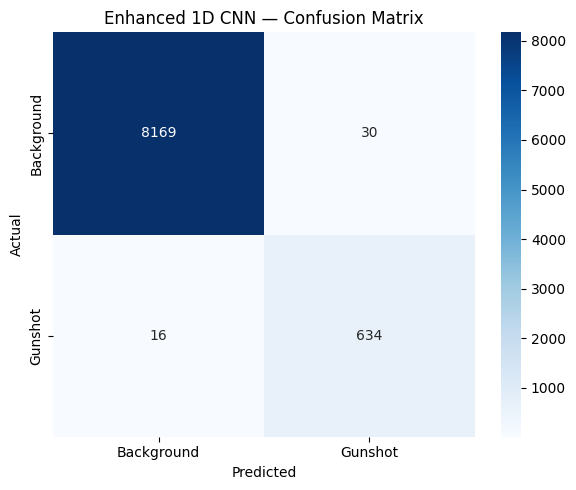


🎯 F2 Score (recall-heavy): 0.9712
🎯 ROC-AUC: 0.9985

💾 Results saved to output


In [19]:
# ============================================================
# CELL 11: Evaluation
# ============================================================

y_pred_gunshot, y_pred_anomaly = model.predict(X_test, verbose=0)
y_pred_binary = (y_pred_gunshot.flatten() >= 0.5).astype(int)

print('\n📊 Classification Report (Gunshot Head):')
print(classification_report(y_test, y_pred_binary, target_names=['Background', 'Gunshot']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Gunshot'],
            yticklabels=['Background', 'Gunshot'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Enhanced 1D CNN — Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'enhanced_1d_cnn_confusion.png', dpi=150)
plt.show()

# F2 Score (emphasizes recall)
f2 = fbeta_score(y_test, y_pred_binary, beta=2)
roc = roc_auc_score(y_test, y_pred_gunshot.flatten())
print(f'\n🎯 F2 Score (recall-heavy): {f2:.4f}')
print(f'🎯 ROC-AUC: {roc:.4f}')

# Save results
results = {
    'f2_score': float(f2), 'roc_auc': float(roc),
    'clip_duration_ms': CLIP_DURATION_MS,
    'augmentations': {'mixup': USE_MIXUP, 'specaugment': USE_SPECAUGMENT,
                      'pitch_shift': USE_PITCH_SHIFT, 'speed_perturb': USE_SPEED_PERTURB},
    'timestamp': datetime.now().isoformat(),
}
with open(OUTPUT_DIR / 'enhanced_1d_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'\n💾 Results saved to {OUTPUT_DIR}')